--- Step 1: Loading Dataset ---
Dataset successfully loaded. Shape: (300, 5)
   CustomerID  Age  Annual_Income_k$  Spending_Score_1to100  \
0        1001   56                46                     67   
1        1002   69                23                     65   
2        1003   46               119                     33   
3        1004   32               113                     40   
4        1005   60                33                     74   

   Purchase_Frequency_PerYear  
0                          12  
1                          40  
2                          39  
3                          35  
4                          39   

--- Step 2: Preprocessing and Scaling Features ---
Features scaled successfully.

--- Step 3: Running Elbow Method ---


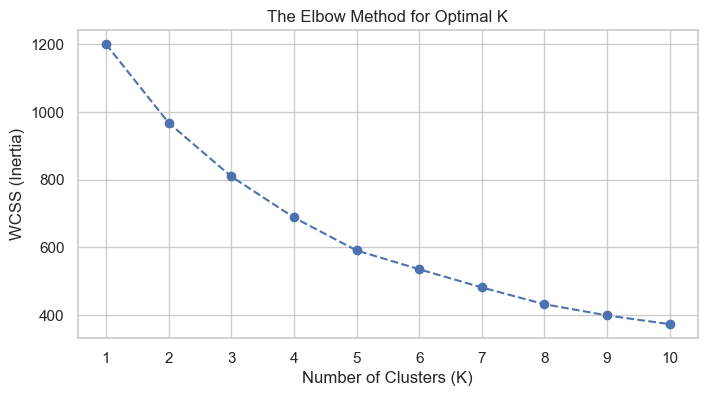

Review the generated plot. For this synthetic dataset, we will proceed with K=4.

--- Step 4: Training Final K-Means Model ---
Clustering complete. Group assignments added to DataFrame.

--- Step 5: Visualizing Segments ---


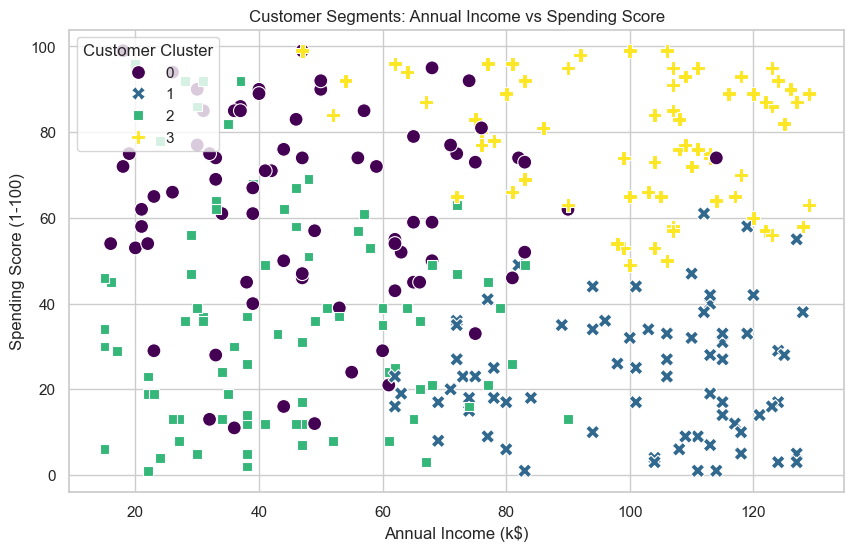

--- Step 6: Generating Segment Profiles (Averages) ---

=== FINAL CUSTOMER PROFILE ANALYSIS ===
           Age  Annual_Income_k$  Spending_Score_1to100  \
Cluster                                                   
0        38.95             48.80                  62.51   
1        44.68            100.30                  23.58   
2        45.27             43.89                  35.77   
3        44.26            100.66                  78.56   

         Purchase_Frequency_PerYear  Customer_Count  
Cluster                                              
0                             39.29              75  
1                             28.10              73  
2                             13.99              84  
3                             19.51              68  


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Set style for high-quality visualizations
sns.set_theme(style="whitegrid")
np.random.seed(42)

# =====================================================================
# STEP 1: SIMULATE / IMPORT DATA
# =====================================================================
# (If you have your own file, replace this section with: df = pd.read_csv('your_file.csv'))
print("--- Step 1: Loading Dataset ---")

n_samples = 300
data = {
    'CustomerID': range(1001, 1001 + n_samples),
    'Age': np.random.randint(18, 70, size=n_samples),
    'Annual_Income_k$': np.random.randint(15, 130, size=n_samples),
    'Spending_Score_1to100': np.random.randint(1, 100, size=n_samples),
    'Purchase_Frequency_PerYear': np.random.randint(2, 50, size=n_samples)
}

df = pd.DataFrame(data)
print(f"Dataset successfully loaded. Shape: {df.shape}")
print(df.head(), "\n")

# =====================================================================
# STEP 2: DATA PREPROCESSING & FEATURE SCALING
# =====================================================================
print("--- Step 2: Preprocessing and Scaling Features ---")

# Selecting features for clustering (Excluding CustomerID)
features = ['Age', 'Annual_Income_k$', 'Spending_Score_1to100', 'Purchase_Frequency_PerYear']
X = df[features]

# K-Means is sensitive to scale, so we normalize to mean=0, variance=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features scaled successfully.\n")

# =====================================================================
# STEP 3: THE ELBOW METHOD (Finding Optimal K)
# =====================================================================
print("--- Step 3: Running Elbow Method ---")

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Graph
plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.show()

print("Review the generated plot. For this synthetic dataset, we will proceed with K=4.\n")

# =====================================================================
# STEP 4: APPLY K-MEANS CLUSTERING
# =====================================================================
print("--- Step 4: Training Final K-Means Model ---")

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Clustering complete. Group assignments added to DataFrame.\n")

# =====================================================================
# STEP 5: VISUALIZATION
# =====================================================================
print("--- Step 5: Visualizing Segments ---")

# Plotting Income vs Spending Score colored by their assigned Cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Annual_Income_k$', 
    y='Spending_Score_1to100', 
    hue='Cluster', 
    palette='viridis', 
    s=100, 
    style='Cluster'
)
plt.title('Customer Segments: Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Customer Cluster')
plt.show()

# =====================================================================
# STEP 6: ANALYZE AND INTERPRET PATTERNS
# =====================================================================
print("--- Step 6: Generating Segment Profiles (Averages) ---")

# Group by Cluster and calculate the average traits of each group
cluster_profiles = df.groupby('Cluster')[features].mean().round(2)
# Add cluster size/count to the profile overview
cluster_profiles['Customer_Count'] = df['Cluster'].value_counts()

print("\n=== FINAL CUSTOMER PROFILE ANALYSIS ===")
print(cluster_profiles)

